# DATA PREPARATION - Data Type Profiler

End-to-end notebook covering:
1. Load data
2. Null value handling
3. Drop Correlated Features
4. Apply PCA on word embeddings
5. Split dataset (train/val/test)

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## 1. Load Data

In [2]:
def load_features(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath)
    print(f"\nDataset shape: {df.shape}")
    # print(df.head(2))
    # print(df.describe())
    return df

def load_and_merge_features(filepaths) -> pd.DataFrame:
    dfs = []
    for filepath in filepaths:
        df = load_features(filepath)
        dfs.append(df)

    merged = pd.concat(dfs, ignore_index=True)
    print(f"\nMerged dataset shape: {merged.shape}")
    return merged

df = load_and_merge_features([
    'data/features_viznet_train_auto_labeled_subset.csv',
    'data/features_non_viznet_auto_labeled.csv',
    'data/features_gittables_auto_labeled.csv'
])


Dataset shape: (200, 2507)

Dataset shape: (1396, 2507)

Dataset shape: (1856, 2507)

Merged dataset shape: (3452, 2507)


## 2. Handle Null Values

In [3]:
df.fillna({'skew_length': 0.0}, inplace=True)
df.fillna({'kurtosis_length': -3.0}, inplace=True)

In [5]:
df.columns[4:98]

Index(['!', '"', '#', '$', '%', '&', ''', '(', ')', '*', '+', ',', '-', '.',
       '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<',
       '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
       'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X',
       'Y', 'Z', '[', '\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f',
       'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't',
       'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~'],
      dtype='object')

In [6]:
print(df.shape)
df = df[~(df.iloc[:, 4:98] == 0).all(axis=1)]
print(df.shape)

(3452, 2507)
(3452, 2507)


In [7]:
df = df.drop(['Filepath', 'column_name_segments', 'num_of_segments'], axis=1)

In [8]:
print(df.shape)
df = df.drop_duplicates()
print(df.shape)


(3452, 2504)
(3188, 2504)


6

Data type distribution:
DataType
number       1410
varchar      1373
boolean       203
date          146
timestamp      54
time            2
Name: count, dtype: int64


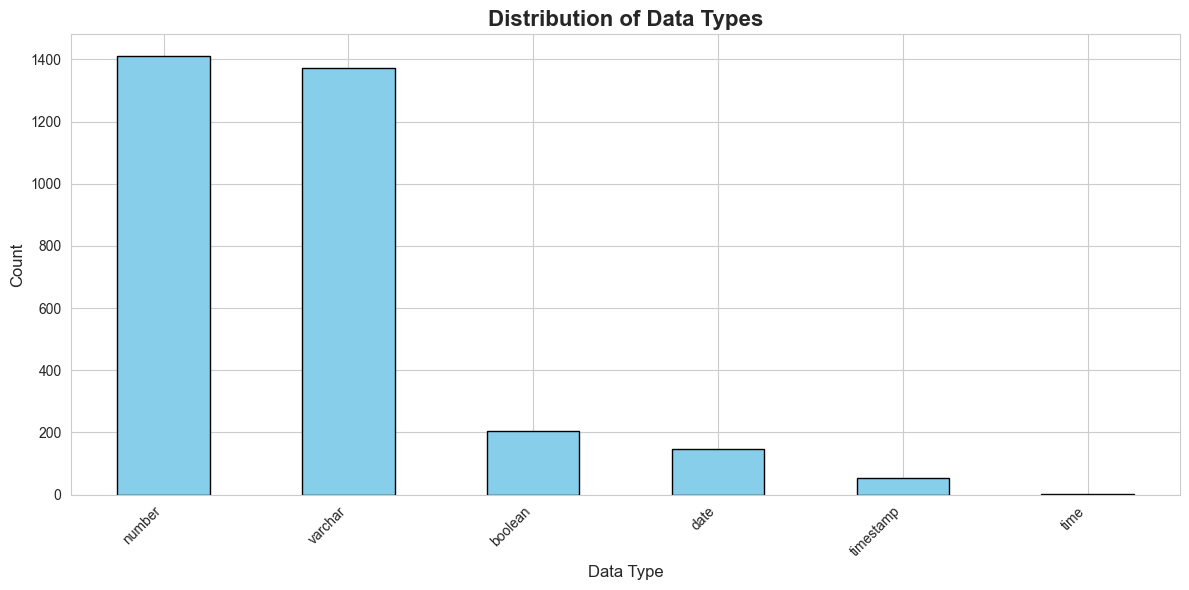

In [9]:
import matplotlib.pyplot as plt

def plot_label_column(df: pd.DataFrame) -> pd.DataFrame:
    print(df['DataType'].nunique())

    datatype_counts = df['DataType'].value_counts()
    print("\nData type distribution:")
    print(datatype_counts)

    # Plot data type distribution
    plt.figure(figsize=(12, 6))
    datatype_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of Data Types', fontsize=16, fontweight='bold')
    plt.xlabel('Data Type', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    # plt.savefig('datatype_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_label_column(df) # will be same for FT_features

## 3. Drop Correlated Features

In [10]:
print('Dataset Shape before dropping features:', df.shape)
drop_feature_names = [']', '}', ')', 'mean_length','skew_length','min_length']
df_filtered = df.drop(columns=drop_feature_names)
print('Dataset Shape after dropping features:', df_filtered.shape)

Dataset Shape before dropping features: (3188, 2504)
Dataset Shape after dropping features: (3188, 2498)


## 5. Apply PCA
n_components = 25

In [11]:
embedding_prefixes = ['emb_w1_', 'emb_w2_', 'emb_w3_', 'emb_w4_',
                          'emb_w5_', 'emb_w6_', 'emb_w7_', 'emb_w8_']
pc_columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
               'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20']
embedding_columns = []
all_emb_data = None

# collect all word embeddings
for prefix in embedding_prefixes:
    emb_cols = [col for col in df_filtered.columns if col.startswith(prefix)]
    embedding_columns.extend(emb_cols)
    emb_data = df_filtered[emb_cols].values.tolist()
    if all_emb_data is None:
        all_emb_data = emb_data
    else:
        all_emb_data.extend(emb_data)

all_emb_data = np.unique(all_emb_data, axis=0)
all_emb_data = np.array(all_emb_data)
print('all_emb_data',all_emb_data.shape)

all_emb_data (1218, 300)


In [12]:
# Fit PCA on all word embeddings
all_emb_df = pd.DataFrame(all_emb_data, columns=[f'emb_{i}' for i in range(all_emb_data.shape[1])])
all_emb_df = all_emb_df.dropna()

scaler = StandardScaler()
scaler.set_output(transform='pandas')
scaled_data = scaler.fit_transform(all_emb_df)

pca = PCA(n_components=25)
principal_components = pca.fit_transform(scaled_data)

In [13]:
# Apply PCA on word embedding columns
pca_df = pd.DataFrame()
for prefix in embedding_prefixes:
    print(f"Processing {prefix[:-1]} embeddings ({len(emb_cols)} dimensions)")
    emb_cols = [col for col in df_filtered.columns if col.startswith(prefix)]
    emb_scaled_data = scaler.transform(
        pd.DataFrame(
            df_filtered[emb_cols].values.tolist(),
            columns=[f'emb_{i}' for i in range(all_emb_data.shape[1])]
        )
    )

    principal_components = pca.transform(emb_scaled_data)

    embedding_pca_df = pd.DataFrame(data=principal_components,
                          columns=[f'{prefix}d{i}' for i in range(principal_components.shape[1])])

    if pca_df.empty:
        pca_df = embedding_pca_df
    else:
        pca_df = pd.concat([pca_df, embedding_pca_df], axis=1)

    print(embedding_pca_df.shape, pca_df.shape)

Processing emb_w1 embeddings (300 dimensions)
(3188, 25) (3188, 25)
Processing emb_w2 embeddings (300 dimensions)
(3188, 25) (3188, 50)
Processing emb_w3 embeddings (300 dimensions)
(3188, 25) (3188, 75)
Processing emb_w4 embeddings (300 dimensions)
(3188, 25) (3188, 100)
Processing emb_w5 embeddings (300 dimensions)
(3188, 25) (3188, 125)
Processing emb_w6 embeddings (300 dimensions)
(3188, 25) (3188, 150)
Processing emb_w7 embeddings (300 dimensions)
(3188, 25) (3188, 175)
Processing emb_w8 embeddings (300 dimensions)
(3188, 25) (3188, 200)


In [14]:
print('Dataset Shape before PCA:', df_filtered.shape)
df_reset = df_filtered.reset_index(drop=True)
print('Dataset Shape after dropping columns:', df_filtered.shape)
print(f"Dropping {len(embedding_columns)} embedding columns")
print(f"Adding {len(pca_df.columns)} PCA embedding columns")
df_final = pd.concat([df_reset.drop(columns=embedding_columns), pca_df], axis=1)
print('Dataset Shape after PCA:', df_final.shape)

Dataset Shape before PCA: (3188, 2498)
Dataset Shape after dropping columns: (3188, 2498)
Dropping 2400 embedding columns
Adding 200 PCA embedding columns
Dataset Shape after PCA: (3188, 298)


## 6. Split Dataset

In [16]:
X = df_final.drop(['DataType', 'PandasDataType'], axis=1)
y = df_final[['DataType', 'PandasDataType']]

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42)

y_train = y_train['DataType']
y_val = y_val['DataType']
y_pandas = y_test['PandasDataType']
y_test = y_test['DataType']

print(f'Training Dataset Shape: ({X_train.shape}, {y_train.shape})')
print(f'Validation Dataset Shape: ({X_val.shape}, {y_val.shape})')
print(f'Test Dataset Shape: ({X_test.shape}, {y_test.shape})')

Training Dataset Shape: ((2231, 296), (2231,))
Validation Dataset Shape: ((669, 296), (669,))
Test Dataset Shape: ((288, 296), (288,))


In [18]:
X_train.to_csv('data/X_train.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
X_val.to_csv('data/X_val.csv', index=False)
y_val.to_csv('data/y_val.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)
y_pandas.to_csv('data/y_pandas.csv', index=False)

In [19]:
print(X_train.columns[0:96])

Index(['ColumnName', '!', '"', '#', '$', '%', '&', ''', '(', '*', '+', ',',
       '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':',
       ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H',
       'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V',
       'W', 'X', 'Y', 'Z', '[', '\', '^', '_', '`', 'a', 'b', 'c', 'd', 'e',
       'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's',
       't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '~', 'max_length',
       'median_length', 'kurtosis_length', 'entropy'],
      dtype='object')
